In [ ]:
HUERISTICS = ['phi']            # Heuristic methods for feature selection
NAMES = ['Phi Correlation']     # Names of the heuristic methods

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from config import IMPUTATION   # whether to use imputed values

TASKS = ['mt', 'dep', 'el', 'pos']

# This file creates multiple graphs to analyze the performace of the feature selected subsets.

## Graph of the category of features selected
i.e in categories: syntactical, morphological, inventory, phonological for feature subset sizes of 0 up to 700 in increments of 100.
The feature subsets should be in a folder named `selection_result`.

In [3]:
def count_features(df: pd.DataFrame) -> tuple[int, int, int, int]:
    """
    Count the number of features in each category (syntactical, morphological, inventory, phonological) from the DataFrame.
    
    Inputs
    ------
    - df: dataframe to count features from
    
    Outputs
    -------
    Number of syntactical features, number of morphological features, number of inventory features, number of phonological features as a tuple.
    """
    n_syntax: int = 0
    n_morphological: int = 0
    n_inventory: int = 0
    n_phonological: int = 0

    for feature in df.columns:
        if feature.startswith('S_'):
            n_syntax += 1
        elif feature.startswith('M_'):
            n_morphological += 1
        elif feature.startswith('INV_'):
            n_inventory += 1
        elif feature.startswith('P_'):
            n_phonological += 1
        else:
            raise ValueError(f"Unknown feature type for {feature}")
        
    return n_syntax, n_morphological, n_inventory, n_phonological

In [4]:
# Get the original feature counts of URIEL+ before feature selection
baseline: pd.DataFrame = pd.read_csv('./data/URIELPlus_Union.csv', index_col=0)
base_syntax, base_morphological, base_inventory, base_phonological = count_features(baseline)

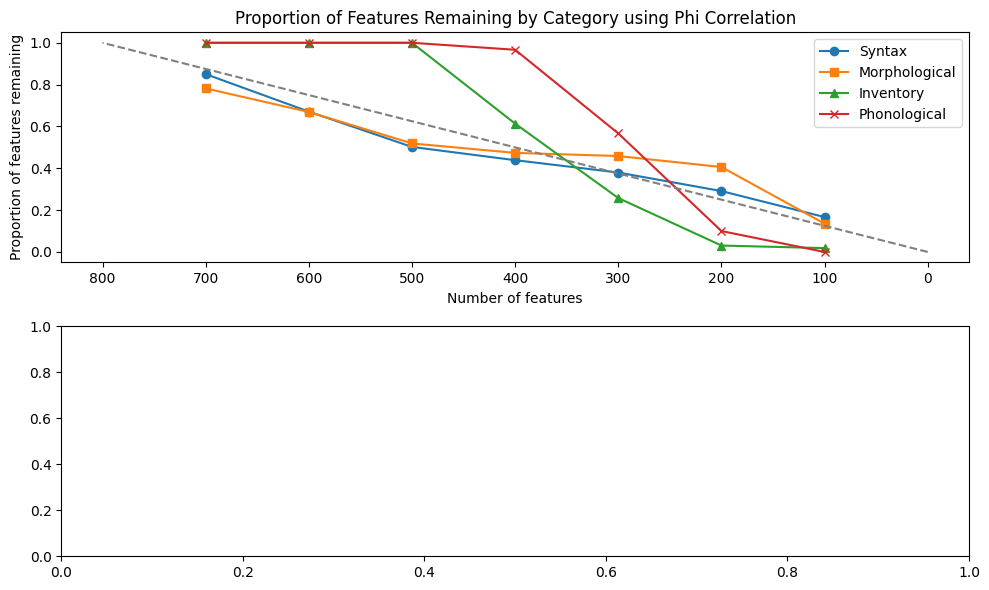

In [ ]:
fig, ax = plt.subplots(len(HUERISTICS)+1, figsize=(10, 6))

for i, hueristic in enumerate(HUERISTICS):
    features: dict[str, list[float]] = {
        'syntax': [],
        'morphological': [],
        'inventory': [], 
        'phonological': []
    }

    for k in range(100, 701, 100):
        df: pd.DataFrame = pd.read_csv(f'selection_result/ant_{hueristic}_{k}.csv', index_col=0)
        
        n_syntax, n_morphological, n_inventory, n_phonological = count_features(df)
        features['syntax'].append(n_syntax / base_syntax)
        features['morphological'].append(n_morphological / base_morphological)
        features['inventory'].append(n_inventory / base_inventory)
        features['phonological'].append(n_phonological / base_phonological)

    ax[i].plot(range(100, 701, 100), features['syntax'], label='Syntax', marker='o')
    ax[i].plot(range(100, 701, 100), features['morphological'], label='Morphological', marker='s')
    ax[i].plot(range(100, 701, 100), features['inventory'], label='Inventory', marker='^')
    ax[i].plot(range(100, 701, 100), features['phonological'], label='Phonological', marker='x')

    # Linear reference line for uniformly distributed features
    ax[i].plot([0, 800], [0, 1], '--', color='gray')

    ax[i].set_title(f'Proportion of Features Remaining by Category using {NAMES[i]}')
    ax[i].set_xlabel('Number of features')
    ax[i].invert_xaxis()
    ax[i].set_ylabel('Proportion of features remaining')
    ax[i].legend()

plt.tight_layout()
plt.show()

# Create graphs for each task

In [ ]:
# Read the data
# mi_data = pd.read_csv('results/mi_results.csv')
# phi_data = pd.read_csv('results/phi_results.csv')
phi_data = pd.read_csv('eval_result/ant_hueristic_phi_results.csv')
baseline_data = pd.read_csv('eval_result/baseline_results_imputed.csv')

# Create a figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

# Metrics to plot (excluding num_features column)
metrics = ['mt', 'dep', 'el', 'pos']
names = ["Machine Translation", "Dependency Parsing", "Entity Linking", "Part-of-Speech Tagging"]

# Create violin plots for each metric
for idx, metric in enumerate(metrics):
    # Prepare data for plotting
    plot_data = pd.DataFrame({
        'Method': ['PHI'] * len(phi_data) + ['PHI'] * len(phi_data),
        'Value': pd.concat([phi_data[metric], phi_data[metric]]),
    })
    
    # Create violin plot
    sns.violinplot(data=plot_data, x='Method', y='Value', hue='Method', ax=axes[idx], split=True)
    axes[idx].set_title(f'{names[idx]}')
    axes[idx].set_ylabel('Value')

    # Add horizontal line for baseline
    baseline_value = baseline_data[metric].iloc[0]
    axes[idx].axhline(y=baseline_value, color='red', linestyle='--', label='Baseline')
    
    axes[idx].set_title(f'{names[idx]}')
    axes[idx].set_ylabel('NDCG@3')
    axes[idx].legend()
    
# Adjust layout
plt.show()

In [ ]:
# Plot average improvement over baseline for each task separately

plt.figure(figsize=(8, 6))
for i, metric in enumerate(metrics):
    baseline_value = baseline_data[metric].iloc[0]
    phi_improvement = (phi_data[metric] - baseline_value) / baseline_value * 100

    plt.subplot(2, 2, i + 1)
    plt.plot(phi_data['num_features'], phi_improvement, marker='o', color='#e74c3c', label='PHI')
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Baseline')
    plt.title(f'{names[i]}')
    plt.xlabel('Number of Features')
    plt.ylabel('Improvement over Baseline (%)')
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()


# Create graph for average of results

In [ ]:
# Calculate average improvements
results: dict[str, dict[str, list[float]]] = {method: {task: [] for task in TASKS} for method in METHODS}

mi_improvements = []
phi_improvements = []

for metric in metrics:
    baseline_value = baseline_data[metric].iloc[0]
    
    # Calculate percentage improvements for this metric
    # mi_improvement = [(val - baseline_value) / baseline_value * 100 for val in mi_data[metric]]
    phi_improvement = [(val - baseline_value) / baseline_value * 100 for val in phi_data[metric]]
    
    # mi_improvements.append(mi_improvement)
    phi_improvements.append(phi_improvement)

# Convert to numpy arrays and calculate mean and std
mi_improvements = np.array(mi_improvements)
phi_improvements = np.array(phi_improvements)

mi_mean = np.mean(mi_improvements, axis=0)
phi_mean = np.mean(phi_improvements, axis=0)

mi_std = np.std(mi_improvements, axis=0)
phi_std = np.std(phi_improvements, axis=0)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot lines with error bands
# plt.plot(mi_data['num_features'], mi_mean, marker='o', color='#2ecc71', 
#          label='MI', linewidth=2)
# plt.fill_between(mi_data['num_features'], 
#                  mi_mean - mi_std, mi_mean + mi_std,
#                  color='#2ecc71', alpha=0.2)

plt.plot(phi_data['num_features'], phi_mean, marker='s', color='#e74c3c', 
         label='PHI', linewidth=2)
plt.fill_between(phi_data['num_features'], 
                 phi_mean - phi_std, phi_mean + phi_std,
                 color='#e74c3c', alpha=0.2)

# Add horizontal line at 0% (baseline)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Customize plot
plt.title('Average Improvement over Baseline Across All Tasks')
plt.xlabel('Number of Features')
plt.ylabel('Average Improvement over Baseline (%)')
plt.grid(True, alpha=0.3)
plt.legend()

# Add value labels on points
# for x, y in zip(mi_data['num_features'], mi_mean):
#     plt.annotate(f'{y:.1f}%', (x, y), textcoords="offset points", 
#                 xytext=(0,10), ha='center', fontsize=10)
for x, y in zip(phi_data['num_features'], phi_mean):
    plt.annotate(f'{y:.1f}%', (x, y), textcoords="offset points", 
                xytext=(0,-15), ha='center', fontsize=10)
plt.show()